In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import spatialdata as sd
from spatialdata_io import xenium
import spatialdata_plot

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [2]:
sc.settings.set_figure_params(dpi=80)

In [3]:
figdir = '/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/Revision_Oct2025/fetal_ms_figures'
os.makedirs(figdir,exist_ok=True)

# Read in adata with cell type labels

In [21]:
objects_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium'
path_adata = f'{objects_dir}/TACCO/tacco-splitted_filtered_celltype-sel_raw.h5ad'
adata = sc.read_h5ad(path_adata,backed='r')
adata

AnnData object with n_obs × n_vars = 239745 × 5001 backed at '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/TACCO/tacco-splitted_filtered_celltype-sel_raw.h5ad'
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'tissue_block_id', 'celltypist_coarse', 'conf_score_coarse', 'celltypist_coarse_fin', 'celltypist_coarse2midmod', 'conf_score_coarse2midmod', 'celltypist_mid_fin', 'celltypist_midmod2fine', 'conf_score_midmod2fine', 'pca_harmony_leiden_0.2', 'pca_harmony_leiden_0.3', 'pca_harmony_leiden_0.4', 'pca_harmony_leiden_0.5'

# Load DAPI image

In [4]:
objects_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium'
# path_adata = f'{objects_dir}/TACCO/tacco-splitted_filtered_celltype-sel_raw.h5ad'
# adata = sc.read_h5ad(path_adata)
# adata

!ls {objects_dir}/zarr

output-XETG00155__0038587__C194-HEA-0-FFPE-1__20241113__134112.zarr
output-XETG00155__0038587__Hst45-HEA-0-FFPE-1__20241113__134112.zarr


In [68]:
sample_id = 'C194-HEA-0-FFPE-1'

In [5]:
xenium_path = f'{objects_dir}/zarr/output-XETG00155__0038587__{sample_id}__20241113__134112.zarr'
sdata = sd.read_zarr(xenium_path)
sdata

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, 

SpatialData object, with associated Zarr store: /rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/zarr/output-XETG00155__0038587__C194-HEA-0-FFPE-1__20241113__134112.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 34038, 51143), (4, 17019, 25571), (4, 8509, 12785), (4, 4254, 6392), (4, 2127, 3196)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (34038, 51143), (17019, 25571), (8509, 12785), (4254, 6392), (2127, 3196)
│     └── 'nucleus_labels': DataTree[yx] (34038, 51143), (17019, 25571), (8509, 12785), (4254, 6392), (2127, 3196)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (146232, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (146232, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (140998, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (146232, 5001)
with coordinate systems:
    ▸ 'global', with elements:
        mo

INFO     Rasterizing image for faster rendering.                                                                   


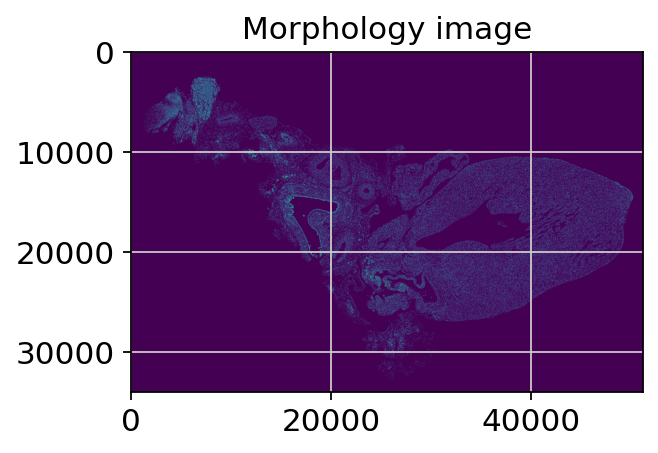

In [6]:
sdata.pl.render_images("morphology_focus", channel="DAPI").pl.show(
    title="Morphology image", coordinate_systems="global", colorbar=False)

In [9]:
%%time
from spatialdata import bounding_box_query
def crop0(x):
    return bounding_box_query(
        x,
        min_coordinate=[22500, 21000],
        max_coordinate=[26000, 24500],
        axes=("x", "y"),
        target_coordinate_system="global",
    )
sdata_cropped = crop0(sdata)

/home/kk837/.conda/envs/generic_env/lib/python3.10/functools.py:889: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


CPU times: user 8min 40s, sys: 1min 8s, total: 9min 49s
Wall time: 1min 48s


In [11]:
from spatialdata import bounding_box_query
def crop0(x):
    return bounding_box_query(
        x,
        min_coordinate=[23600, 22300],
        max_coordinate=[25100, 23600],
        axes=("x", "y"),
        target_coordinate_system="global",
    )
sdata_cropped2 = crop0(sdata)

/home/kk837/.conda/envs/generic_env/lib/python3.10/functools.py:889: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


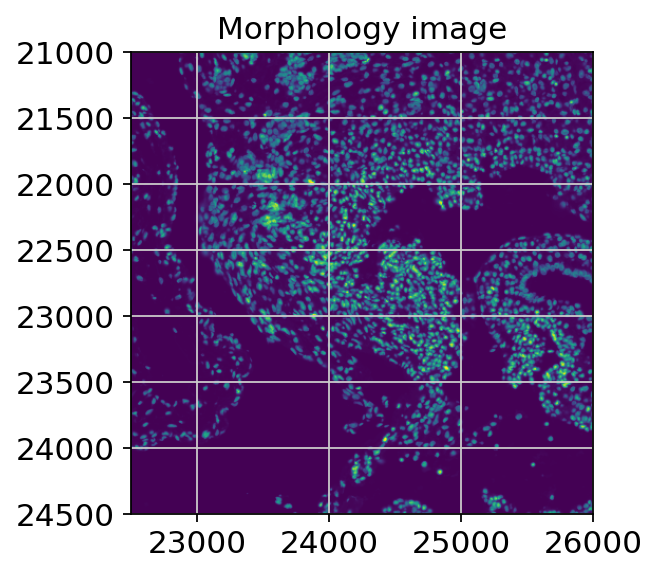

In [10]:
sdata_cropped.pl.render_images("morphology_focus", channel="DAPI").pl.show(
    title="Morphology image", coordinate_systems="global", colorbar=False)

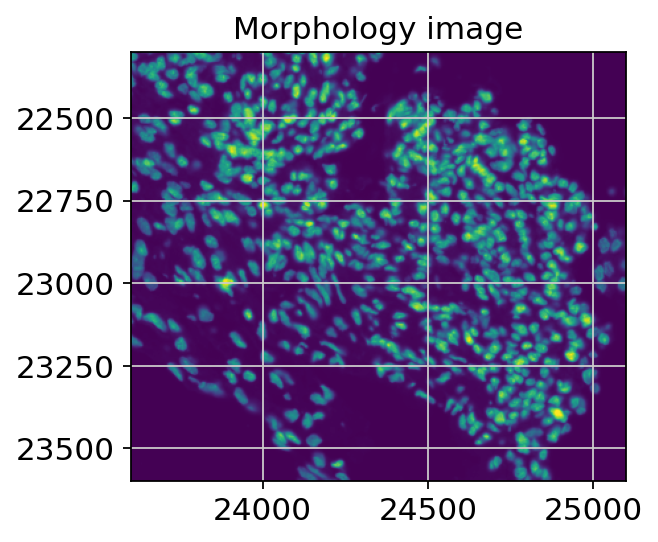

In [12]:
sdata_cropped2.pl.render_images("morphology_focus", channel="DAPI").pl.show(
    title="Morphology image", coordinate_systems="global", colorbar=False)

In [36]:
sdata_cropped2.tables["table"].obs['cell_id_2'] = f'{sample_id}_'+sdata_cropped2.tables["table"].obs['cell_id']
cell_id_order = sdata_cropped2.tables["table"].obs['cell_id_2'].copy()
sdata_cropped2.tables["table"].obs['fine_grain_17Apr2026'] = list(adata.obs['fine_grain_17Apr2026'].reindex(cell_id_order))
sdata_cropped2.tables["table"].obs['fine_grain_17Apr2026'].fillna('nan',inplace=True)
sdata_cropped2.tables["table"].obs['fine_grain_17Apr2026'].value_counts()

/tmp/ipykernel_2631171/3273919508.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sdata_cropped2.tables["table"].obs['fine_grain_17Apr2026'].fillna('nan',inplace=True)


fine_grain_17Apr2026
Fibroblasts                          227
nan                                  189
SinoatrialNodePacemakerCells         157
VentricularCardiomyocytesCycling      47
ParasympatheticNeurons                37
AtrialCardiomyocytesRight             24
VentricularCardiomyocytes             23
MesothelialEpicardialCells            18
CoronaryPericytes                     14
AtrialCardiomyocytesCycling           10
AtrialCardiomyocytesTransitional       9
CoronaryVenousEndothelialCells         8
MacrophagesLYVE1pos                    7
GreatVesselSmoothMuscleCells           5
CoronaryCapillaryEndothelialCells      4
AtrialCardiomyocytesLeft               3
SchwannCells                           3
NeuralCellsCycling                     1
Name: count, dtype: int64

Scale (x, y)
    [4.70588235 4.70588235]
ParasympatheticNeurons 37
SinoatrialNodePacemakerCells 157


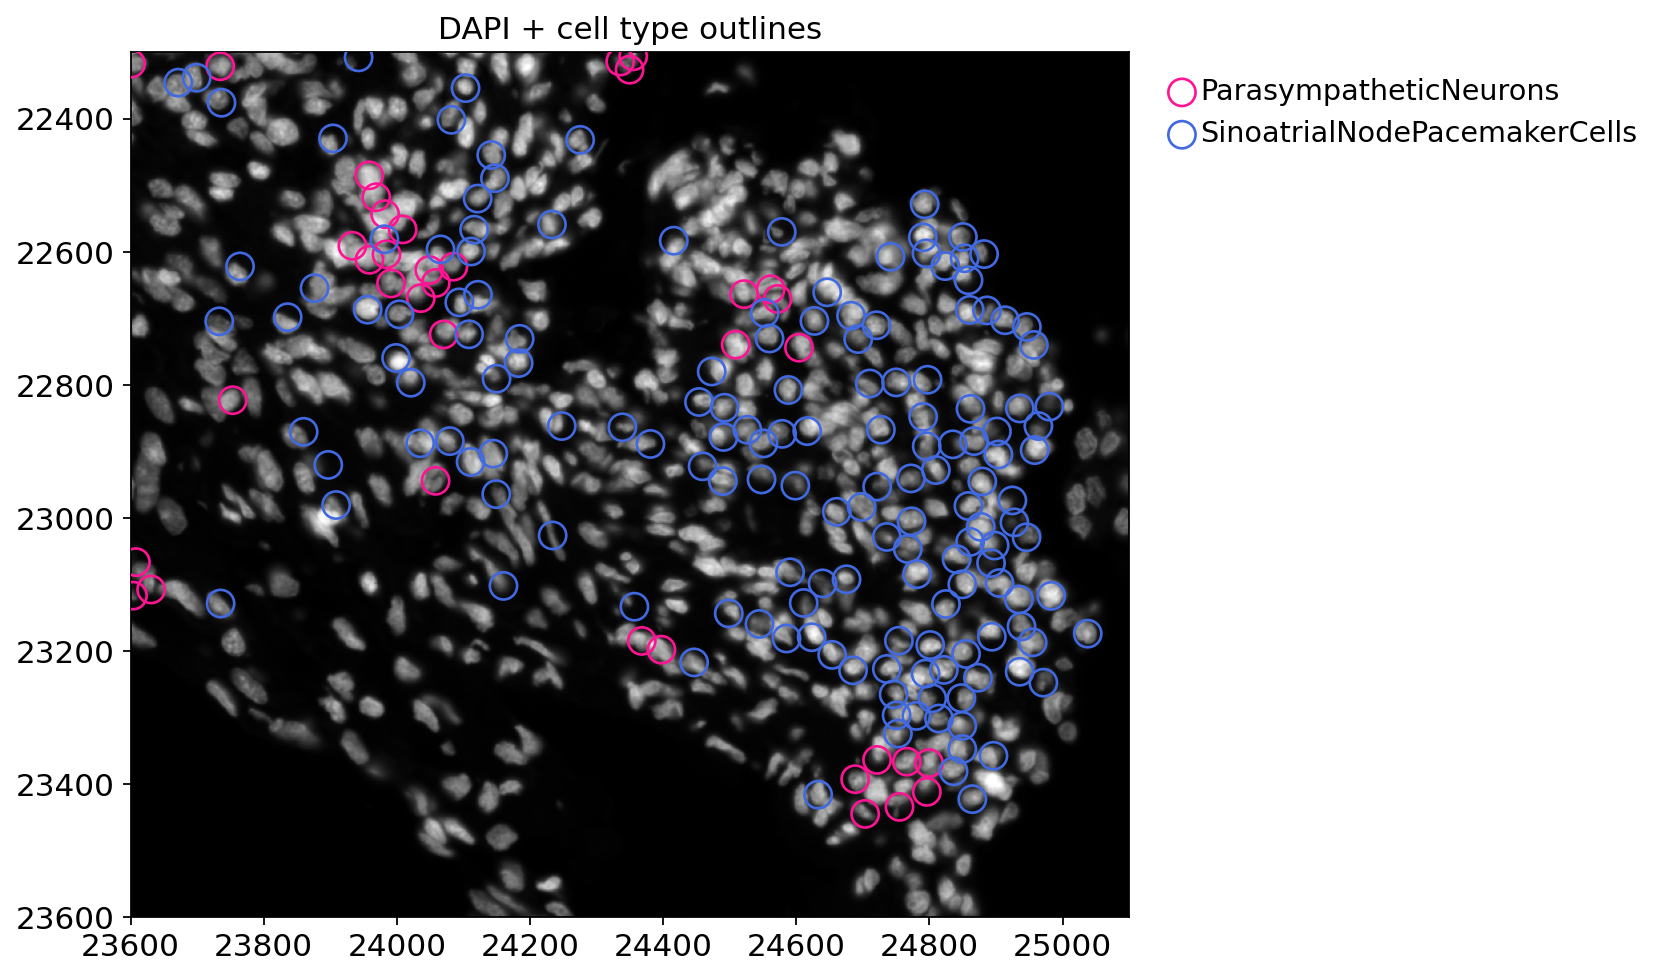

In [67]:
import matplotlib.pyplot as plt
from spatialdata.transformations import get_transformation
from spatialdata import transform

# inspect transform to global
print(get_transformation(sdata_cropped2.shapes["cell_circles"], to_coordinate_system="global"))

# transform shapes into the same coordinate system as the rendered image
cell_circles_global = transform(
    sdata_cropped2.shapes["cell_circles"],
    to_coordinate_system="global"
)

# keep your annotation mapping from before
# gdf2 was your merged dataframe with fine_grain_17Apr2026 attached
gdf_plot = cell_circles_global.copy()
gdf_plot["fine_grain_17Apr2026"] = gdf2["fine_grain_17Apr2026"].values

cent = gdf_plot.geometry.centroid

palette = {
    "ParasympatheticNeurons": "deeppink",
    "SinoatrialNodePacemakerCells": "royalblue",
}

fig, ax = plt.subplots(figsize=(8, 8))

sdata_cropped2.pl.render_images(
    "morphology_focus",
    channel="DAPI",
    cmap="gray"
).pl.show(
    ax=ax,
    coordinate_systems="global",
    colorbar=False,
    title="DAPI + cell type outlines"
)

for ct, color in palette.items():
    mask = gdf_plot["fine_grain_17Apr2026"] == ct
    print(ct, mask.sum())
    if mask.sum() == 0:
        continue

    ax.scatter(
        cent.x[mask],
        cent.y[mask],
        s=150,
        facecolors="none",
        edgecolors=color,
        linewidths=1.2,
        label=ct,
        zorder=10,
    )

ax.grid(False)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.savefig(f'{figdir}/Xenium5K_SAN-zoom-in_DAPI-SANPC-ParaN_C194-HEA-0-FFPE-1.pdf',
                bbox_inches="tight",dpi=300)
plt.show()